<a href="https://colab.research.google.com/github/mohammadhadiGhadam/Machine_Learning_2024/blob/main/Machin_Learning_HW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 💠**First question of mini project 1**

In [ ]:
#import dataset
!gdown  16-R840C0owE9VG7QyR7Iupnw4aBfZ6_J
!ls # this give us the name of dataset

#install libraries that are requiared
!pip install imbalanced-learn

Downloading...
From: https://drive.google.com/uc?id=16-R840C0owE9VG7QyR7Iupnw4aBfZ6_J
To: /content/BankChurners.csv
100% 1.51M/1.51M [00:00<00:00, 157MB/s]
BankChurners.csv  sample_data
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.3/258.3 kB 4.2 MB/s eta 0:00:00


💠Data properties 1.1

In [ ]:
import pandas as pd

#load the file
file = "BankChurners.csv"
data = pd.read_csv(file)

#information for q1.1
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

💠 Data ⅾistribution 1.2

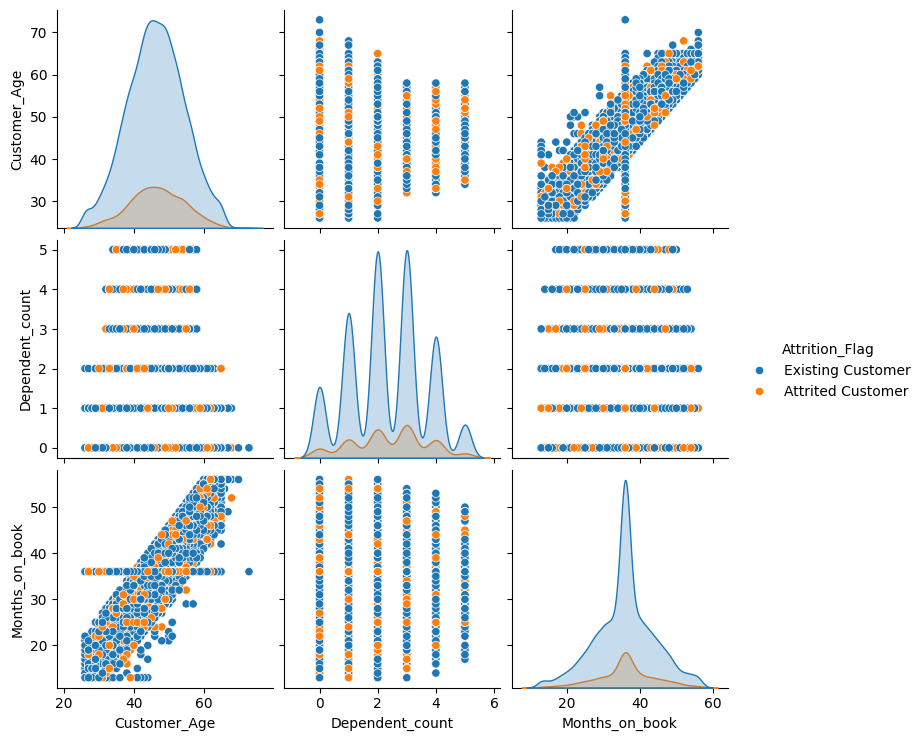

In [ ]:
# part 1.2

import seaborn as sns #library that creates a grid of scatter plots to visualize pairwise relationships
import matplotlib.pyplot as plt

selected_features = ['Customer_Age','Dependent_count','Attrition_Flag','Months_on_book']
data_subset = data[selected_features]
sns.pairplot(data_subset,hue = 'Attrition_Flag')
plt.show()


💠 whole data

💠 Heatmap 1.3

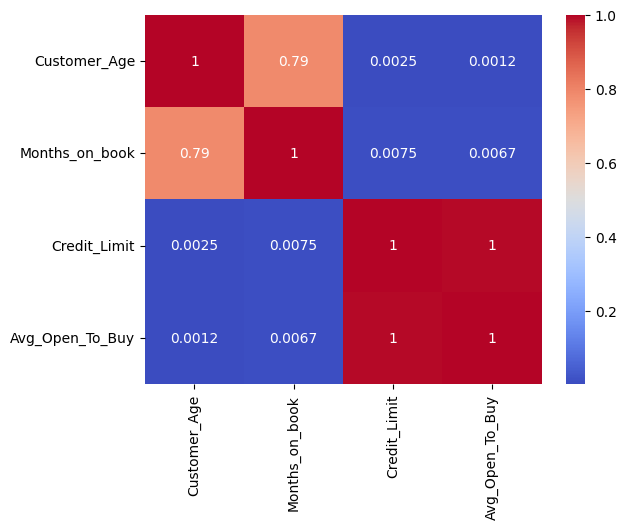

In [ ]:
# part 1.3

# selecting ⅽategoriⅽaⅼ and  ⅽontinuous features
selected_features = ['Customer_Age','Months_on_book','Credit_Limit','Avg_Open_To_Buy']
selected_data = data[selected_features]
# calculate the coralation
correlation_mat = selected_data.corr()
sns.heatmap(correlation_mat,annot = True,cmap = 'coolwarm')
plt.show()

💠Nan detection 1.4

In [ ]:
# part 1.4

data_cleaned = data[~data.isin(["Unknown"]).any(axis=1)]  # Remove rows with "Unknown"
unknown_counts = (data_cleaned == "Unknown").sum()
print(unknown_counts)

CLIENTNUM                                                                                                                             0
Attrition_Flag                                                                                                                        0
Customer_Age                                                                                                                          0
Gender                                                                                                                                0
Dependent_count                                                                                                                       0
Education_Level                                                                                                                       0
Marital_Status                                                                                                                        0
Income_Category                                 

💠Atrrition Flag features 1.5

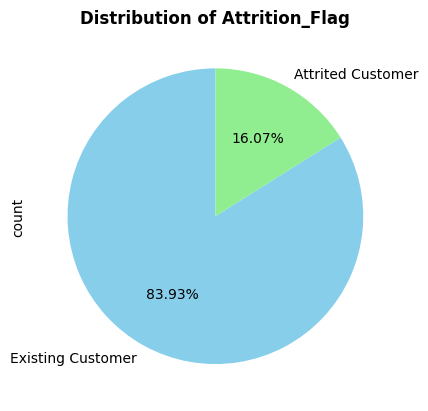

In [ ]:
# part 1.5

Class_Atrittion_count = data['Attrition_Flag'].value_counts()
Class_Atrittion_count.plot.pie(autopct='%1.2f%%', startangle=90, colors=['skyblue', 'lightgreen'])
plt.title("Distribution of Attrition_Flag",fontweight='bold')
plt.show()

**💠 designing the NN**

💠 Removing the Client column

In [ ]:
data_cleaned = data_cleaned.drop(columns = ['CLIENTNUM'])

⚙️splitting the dataset

In [ ]:
from sklearn.model_selection import train_test_split #for splitting the dataset

inputs = data_cleaned.drop(columns = ['Attrition_Flag']) # Inputs: All columns except Attrition_Flag
outputs = data_cleaned['Attrition_Flag'] # Output: Attrition_Flag

⚙️ one-hot encoding

In [ ]:
# Perform one-hot encoding on categorical features
categorical_features = inputs.select_dtypes(include=['object']).columns
inputs = pd.get_dummies(inputs, columns=categorical_features, drop_first=True)

⚙️ measure the correlation

In [ ]:
from sklearn.preprocessing import LabelEncoder
outputs = LabelEncoder().fit_transform(outputs)


# Convert outputs to a DataFrame to allow easy correlation computation
outputs_df = pd.DataFrame(outputs, columns=['Output'])

# Combine inputs and outputs for correlation calculation
combined_data = pd.concat([inputs, outputs_df.reset_index(drop=True)], axis=1)

# Compute the correlation matrix
correlation_matrix = combined_data.corr()

# Extract correlations of all input features with the output
correlation_with_output = correlation_matrix['Output'].sort_values(ascending=False)

# Display the correlations
print("Correlation of Input Features with Output:")
print(correlation_with_output)


Correlation of Input Features with Output:
Output                                                                                                                                1.000000
Marital_Status_Married                                                                                                                0.038096
Gender_M                                                                                                                              0.036927
Total_Amt_Chng_Q4_Q1                                                                                                                  0.027686
Income_Category_$60K - $80K                                                                                                           0.024873
Education_Level_Post-Graduate                                                                                                         0.024278
Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education

⚙️ makeing the corrected data

In [ ]:
outputs = data_cleaned['Attrition_Flag'] # Output: Attrition_Flag

⚙️ splitting into test and learn data

In [ ]:
# Split the dataset into training (70%) and temporary (30%) datasets
Input_train, Input_temp, Output_train, Output_temp = train_test_split(inputs, outputs, test_size = 0.3,random_state=42, stratify = outputs)
# Split the temporary dataset into validation (15%) and test (15%) datasets
Input_val, Input_test, Output_val, Output_test = train_test_split( Input_temp, Output_temp, test_size=0.5,random_state=42, stratify=Output_temp)

⚙️Classification Algorithm in Scikit-learn

*Logistic Regression*

Fitting 5 folds for each of 36 candidates, totalling 180 fits


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Best Parameters: {'C': 0.1, 'max_iter': 5000, 'solver': 'lbfgs'}


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Validation Set Accuracy: 1.00

Validation Classification Report:
                   precision    recall  f1-score   support

Attrited Customer       1.00      1.00      1.00       167
Existing Customer       1.00      1.00      1.00       895

         accuracy                           1.00      1062
        macro avg       1.00      1.00      1.00      1062
     weighted avg       1.00      1.00      1.00      1062


Test Set Accuracy: 1.00

Test Classification Report:
                   precision    recall  f1-score   support

Attrited Customer       1.00      1.00      1.00       167
Existing Customer       1.00      1.00      1.00       896

         accuracy                           1.00      1063
        macro avg       1.00      1.00      1.00      1063
     weighted avg       1.00      1.00      1.00      1063



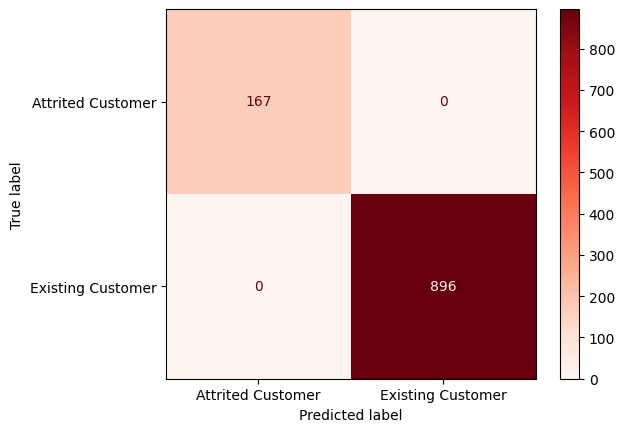

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# Define a parameter grid for Logistic Regression
param_grid = {
    'C': [0.1, 1, 10, 100],  # Regularization strength
    'solver': ['lbfgs', 'liblinear', 'saga'],  # Solvers
    'max_iter': [5000, 10000, 15000],  # Maximum iterations
}

# Create a Logistic Regression model
model = LogisticRegression(random_state=42)

# Use GridSearchCV to find the best parameters
grid_search = GridSearchCV(
    model, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)
grid_search.fit(Input_train, Output_train)

# Display the best parameters
print(f"Best Parameters: {grid_search.best_params_}")

# Train the best model on the entire training set
best_model = grid_search.best_estimator_
best_model.fit(Input_train, Output_train)

# Evaluate the model on the validation set
val_accuracy = best_model.score(Input_val, Output_val)
val_pred = best_model.predict(Input_val)
print(f"\nValidation Set Accuracy: {val_accuracy:.2f}")
print("\nValidation Classification Report:")
print(classification_report(Output_val, val_pred))

# Evaluate the best model on the test set
test_accuracy = best_model.score(Input_test, Output_test)
test_pred = best_model.predict(Input_test)
print(f"\nTest Set Accuracy: {test_accuracy:.2f}")
print("\nTest Classification Report:")
print(classification_report(Output_test, test_pred))

# Compute the confusion matrix for the test set
conf_matrix = confusion_matrix(Output_test, test_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=best_model.classes_)
disp.plot(cmap="Reds")  # Set the colormap to green


💠with Balanced data

Fitting 5 folds for each of 36 candidates, totalling 180 fits


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Best Parameters: {'C': 0.1, 'max_iter': 1000, 'solver': 'lbfgs'}


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Validation Classification Report:
                   precision    recall  f1-score   support

Attrited Customer       1.00      1.00      1.00       167
Existing Customer       1.00      1.00      1.00       895

         accuracy                           1.00      1062
        macro avg       1.00      1.00      1.00      1062
     weighted avg       1.00      1.00      1.00      1062


Test Classification Report:
                   precision    recall  f1-score   support

Attrited Customer       1.00      1.00      1.00       167
Existing Customer       1.00      1.00      1.00       896

         accuracy                           1.00      1063
        macro avg       1.00      1.00      1.00      1063
     weighted avg       1.00      1.00      1.00      1063



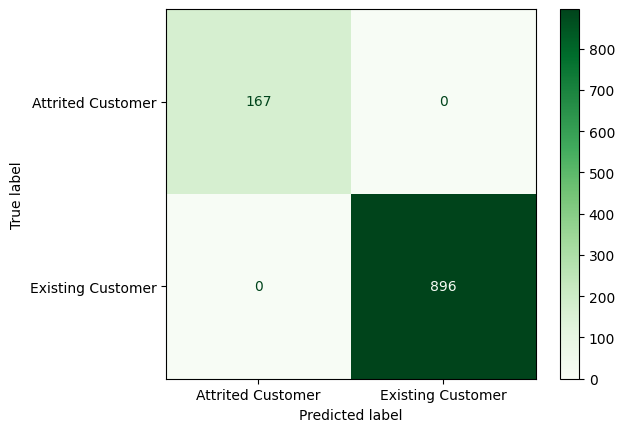

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Balance the dataset using SMOTE
smote = SMOTE(random_state=42)
Input_train_balanced, Output_train_balanced = smote.fit_resample(Input_train, Output_train)

# Define parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear', 'saga'],
    'max_iter': [500, 1000, 1500],
}

# Create Logistic Regression model with class weights
model = LogisticRegression(class_weight='balanced', random_state=42)

# Use GridSearchCV
grid_search = GridSearchCV(
    model, param_grid, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=1
)
grid_search.fit(Input_train_balanced, Output_train_balanced)

# Best parameters
print(f"Best Parameters: {grid_search.best_params_}")

# Train the best model
best_model = grid_search.best_estimator_
best_model.fit(Input_train_balanced, Output_train_balanced)

# Validation evaluation
val_pred = best_model.predict(Input_val)
print("\nValidation Classification Report:")
print(classification_report(Output_val, val_pred))

# Test evaluation
test_pred = best_model.predict(Input_test)
print("\nTest Classification Report:")
print(classification_report(Output_test, test_pred))

# Confusion matrix for test set
conf_matrix = confusion_matrix(Output_test, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=best_model.classes_)
disp.plot(cmap="Greens")


# **💠 Secend question of mini project 1**

💠 importing the data (part 0)

In [ ]:
import gdown
file_id = "1PeQVXfT-aYBH0V1mn7ovo6yp3fq7WjdK"
direct_url = f"https://drive.google.com/uc?id={file_id}"
#import dataset
output_file = "BankData.npy"  # Save as this file name locally
gdown.download(direct_url, output_file, quiet=False)


Downloading...
From: https://drive.google.com/uc?id=1PeQVXfT-aYBH0V1mn7ovo6yp3fq7WjdK
To: /content/BankData.npy
100%|██████████| 928/928 [00:00<00:00, 2.66MB/s]


'BankData.npy'

💠 reading the data

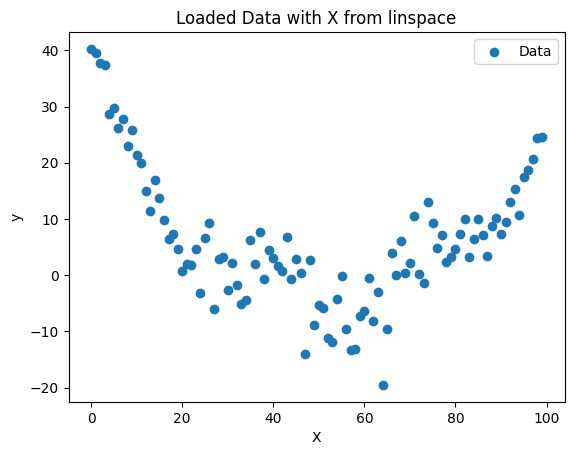

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# Load the file using np.load()
y = np.load(output_file)
X = np.linspace(0, len(y) - 1, len(y))
y = y[~np.isnan(y)]

plt.scatter(X, y, marker='o', label="Data")
plt.title("Loaded Data with X from linspace")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

💠 splitting into test and learn data (part 1)

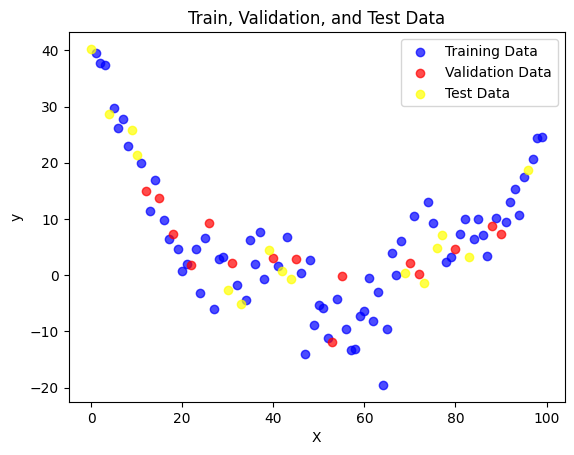

Training set size: 70
Validation set size: 15
Test set size: 15


In [ ]:
from sklearn.model_selection import train_test_split

# Split into training (70%) and temporary (30%) datasets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

# Split the temporary dataset into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Plot the training set
plt.scatter(X_train, y_train, color='blue', label='Training Data', alpha=0.7)

# Plot the validation set
plt.scatter(X_val, y_val, color='red', label='Validation Data', alpha=0.7)

# Plot the test set
plt.scatter(X_test, y_test, color='yellow', label='Test Data', alpha=0.7)

# Add plot details
plt.title("Train, Validation, and Test Data")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

print("Training set size:", X_train.shape[0])
print("Validation set size:", X_val.shape[0])
print("Test set size:", X_test.shape[0])


💠 Define a function for evaluation (part 2)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Assuming y_true are actual values and y_pred are predicted values
def evaluate_regression_model(y_true, y_pred):
    # Calculate metrics
    MSE = mean_squared_error(y_true, y_pred)
    MAE = mean_absolute_error(y_true, y_pred)
    R2 = r2_score(y_true, y_pred)

    # Print results
    print(f"Mean Squared Error (MSE): {MSE:.2f}")
    print(f"Mean Absolute Error (MAE): {MAE:.2f}")
    print(f"R-Squared (R²): {R2:.2f}")

💠 Code for Training Linear Regression (part 3)

In [ ]:
# Define the function for linear regression training
def train_linear_regression(X, y):
    """
    Parameters:
    X (array): Input features
    y (array): Target variable

    Returns:
    m (float): Slope of the line
    b (float): Intercept of the line
    """
    # Calculate the mean of X and y
    x_mean = np.mean(X)
    y_mean = np.mean(y)

    # Calculate the slope (m)
    numerator = np.sum((X - x_mean) * (y - y_mean))
    denominator = np.sum((X - x_mean)**2)

    if np.isclose(denominator, 0):
        m = 0.0  # Assign a slope of 0
    else:
        m = numerator / denominator

    # Calculate the intercept (b)
    b = y_mean - m * x_mean

    return m, b

💠 Train and make the model

In [ ]:
# Train the model
m, b = train_linear_regression(X_train, y_train)

💠 fun for Prediction

In [ ]:
# Define the prediction function
def predict(X, m, b):
    return m * X + b


💠 checking the model

In [ ]:
# Predict on test data
y_test_pred = predict(X_test, m, b)

# Evaluate the model
evaluate_regression_model(y_test, y_test_pred)

Mean Squared Error (MSE): 155.42
Mean Absolute Error (MAE): 9.73
R-Squared (R²): 0.12


💠 Visualizing Results

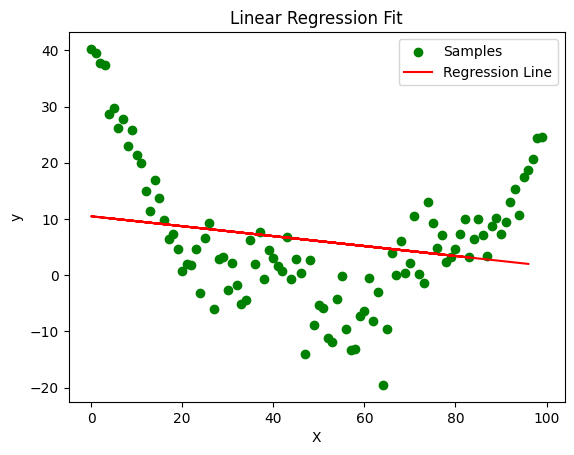

In [ ]:
# Plot the regression line along with the test data
plt.scatter(X, y, color='Green', label='Samples')
plt.plot(X_test, y_test_pred, color='red', label='Regression Line')
plt.title("Linear Regression Fit")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

💠 show the error graph for train and test samples (part 4)

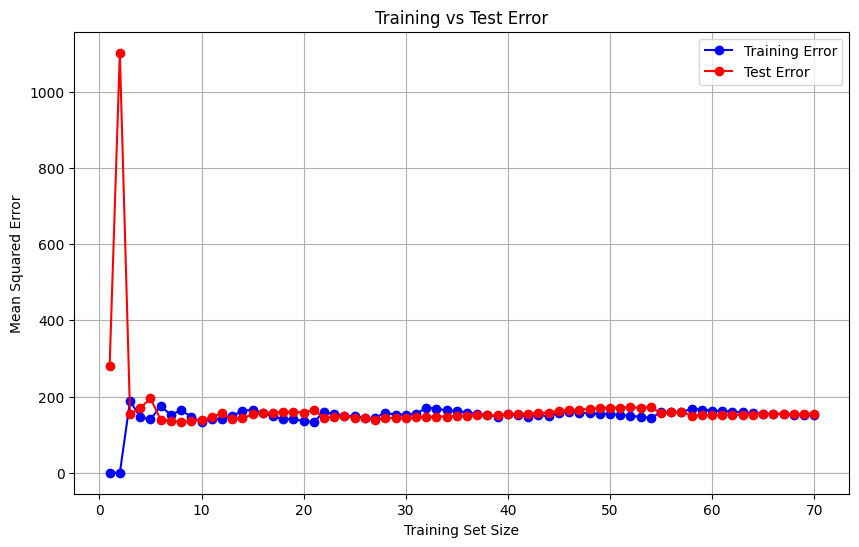

In [ ]:
# Initialize arrays to store errors
train_errors = []
test_errors = []

# Divide training set into 20 incremental steps
steps = np.linspace(1, len(X_train), len(X_train), dtype=int)

for step in steps:
    # Subset of training data (incremental size)
    X_train_subset = X_train[:step]
    y_train_subset = y_train[:step]

    # Train the linear regression model
    m, b = train_linear_regression(X_train_subset, y_train_subset)

    # Predict on training and test sets
    y_train_pred = predict(X_train_subset, m, b)
    y_test_pred = predict(X_test, m, b)

    # Compute errors
    train_mse = mean_squared_error(y_train_subset, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    # Store errors
    train_errors.append(train_mse)
    test_errors.append(test_mse)

# Plot the train and test errors
plt.figure(figsize=(10, 6))
plt.plot(steps, train_errors, label="Training Error", marker='o', color='blue')
plt.plot(steps, test_errors, label="Test Error", marker='o', color='red')
plt.title("Training vs Test Error")
plt.xlabel("Training Set Size")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid()
plt.show()


💠 adding polinomial terms (function)

In [ ]:
# Polynomial regression function
def train_polynomial_regression(X, y, degree):
    # Create polynomial features (e.g., 1, x, x^2, ..., x^degree)
    X_poly = np.vander(X, degree + 1, increasing=True)

    # Solve for coefficients using least squares
    coefficients = np.linalg.lstsq(X_poly, y, rcond=None)[0]
    return coefficients

# Prediction function
def predict_polynomial(X, coefficients):
    """
    Predict values using the polynomial regression model.

    Parameters:
    X (array): Input features
    coefficients (array): Coefficients of the polynomial

    Returns:
    y_pred (array): Predicted values
    """
    X_poly = np.vander(X, len(coefficients), increasing=True)
    return np.dot(X_poly, coefficients)

💠 part 6

Degree 1 coefficients: [10.48038282 -0.08830598]
Degree 2 coefficients: [ 3.44250402e+01 -1.51633628e+00  1.42194977e-02]
Degree 3 coefficients: [ 3.87102004e+01 -2.04003558e+00  2.72801808e-02 -8.65862666e-05]
Degree 4 coefficients: [ 4.19181451e+01 -2.70302378e+00  5.75038597e-02 -5.61335684e-04
  2.39093490e-06]
Degree 5 coefficients: [ 4.51026013e+01 -3.67817512e+00  1.25465423e-01 -2.35825815e-03
  2.24491417e-05 -7.97292299e-08]


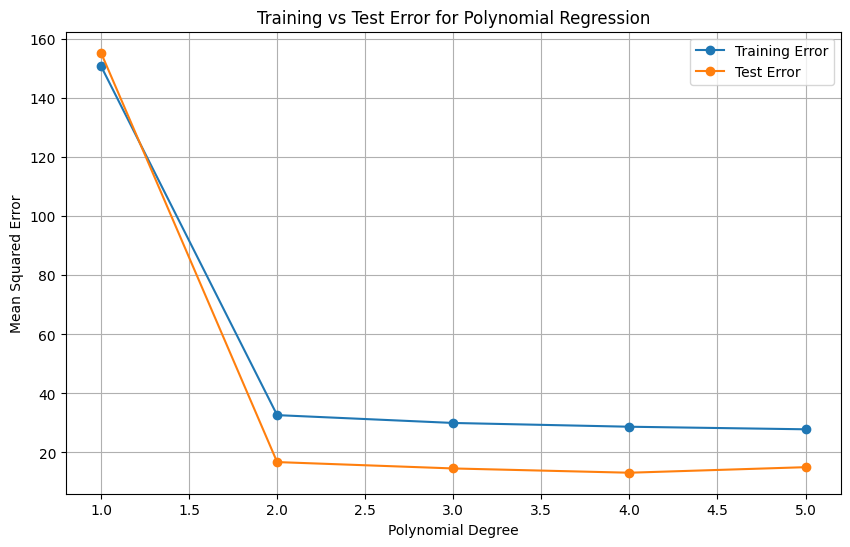

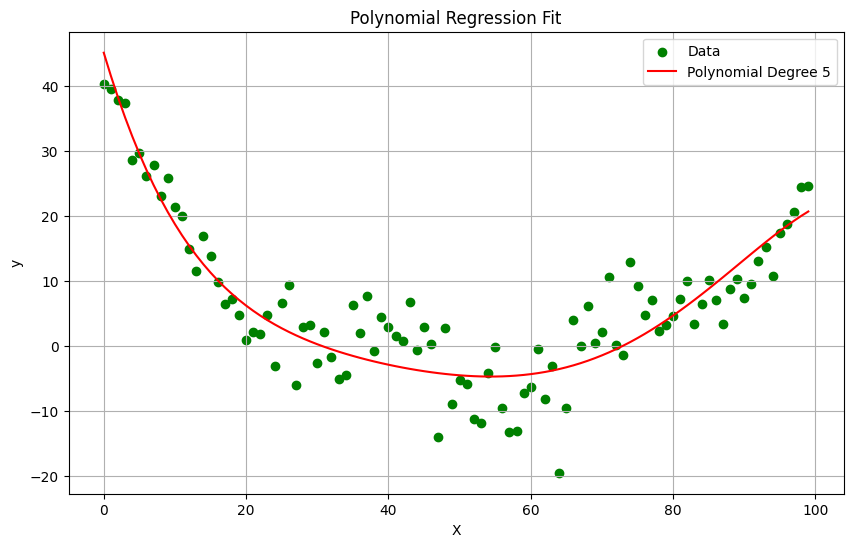

In [ ]:
# Train and evaluate polynomial models of increasing degree
degrees = [1, 2, 3, 4, 5]  # Degrees of the polynomial
train_errors = []
test_errors = []

for degree in degrees:
    # Train the polynomial regression model
    coefficients = train_polynomial_regression(X_train, y_train, degree)

    # Predict on training and test sets
    y_train_pred = predict_polynomial(X_train, coefficients)
    y_test_pred = predict_polynomial(X_test, coefficients)

    # Compute errors
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    train_errors.append(train_mse)
    test_errors.append(test_mse)

    # Print coefficients
    print(f"Degree {degree} coefficients:", coefficients)

# Plot the training and test errors for each degree
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_errors, label="Training Error", marker='o')
plt.plot(degrees, test_errors, label="Test Error", marker='o')
plt.title("Training vs Test Error for Polynomial Regression")
plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid()
plt.show()

# Visualize the best-fitting polynomial (highest degree for illustration)
best_degree = degrees[-1]
best_coefficients = train_polynomial_regression(X_train, y_train, best_degree)
X_sorted = np.sort(X)  # Sort X for smoother plotting
y_best_fit = predict_polynomial(X_sorted, best_coefficients)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='green', label='Data')
plt.plot(X_sorted, y_best_fit, color='red', label=f"Polynomial Degree {best_degree}")
plt.title("Polynomial Regression Fit")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()

💠 part 7

Linear Regression - Mean Squared Error: 47459.99
Ridge Regression - Mean Squared Error: 47373.24
Random Forest Regressor - Mean Squared Error: 10761.03


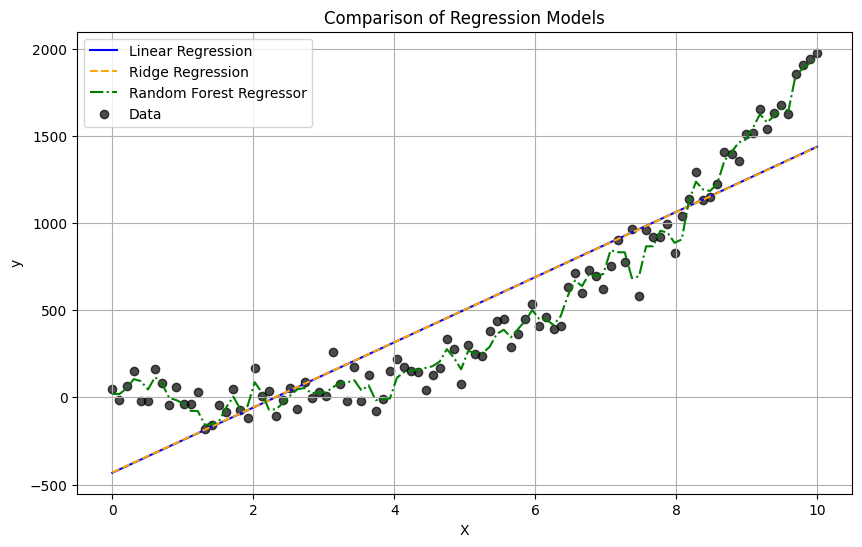


Model Performance (MSE):
Linear Regression: 47459.99
Ridge Regression: 47373.24
Random Forest Regressor: 10761.03


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

# Generate synthetic data (replace with real data if available)
np.random.seed(42)
X = np.linspace(0, 10, 100).reshape(-1, 1)  # Reshape for compatibility with scikit-learn
y = 5 * X.flatten() - 0.5 * X.flatten()**2 + 2 * X.flatten()**3 + np.random.normal(0, 100, size=100)

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42)
}

# Train each model and evaluate performance
results = {}
colors = {"Linear Regression": "blue", "Ridge Regression": "orange", "Random Forest Regressor": "green"}
line_styles = {"Linear Regression": "-", "Ridge Regression": "--", "Random Forest Regressor": "-."}

plt.figure(figsize=(10, 6))
for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)

    # Predict on test data
    y_test_pred = model.predict(X_test)

    # Calculate Mean Squared Error
    mse = mean_squared_error(y_test, y_test_pred)
    results[name] = mse
    print(f"{name} - Mean Squared Error: {mse:.2f}")

    # Predict on sorted X values for visualization
    X_sorted = np.sort(X, axis=0)
    y_curve = model.predict(X_sorted)

    # Plot predictions with unique style
    plt.plot(X_sorted, y_curve, label=name, color=colors[name], linestyle=line_styles[name])

# Plot the original data
plt.scatter(X, y, color="black", label="Data", alpha=0.7)

# Add plot details
plt.title("Comparison of Regression Models")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()

# Compare results
print("\nModel Performance (MSE):")
for name, mse in results.items():
    print(f"{name}: {mse:.2f}")